# EX 5B – Baseball Databank

Same trend/category/distribution/scatter visualization structure as the friend's EX 5B, with Baseball year, league, fielding position and batting statistics.

In [1]:
from pathlib import Path

def find_data(filename):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("../data") / filename,
        Path("../../data") / filename,
        Path("/content") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{filename} not found. Upload the Baseball Databank CSV or keep it in the repository data folder.")

import pandas as pd
import matplotlib.pyplot as plt

batting = pd.read_csv(find_data("Batting.csv"))
fielding = pd.read_csv(find_data("Fielding.csv"))

print("Baseball datasets loaded successfully")
print("Rows:", len(batting))
print("Columns:", len(batting.columns))

Baseball datasets loaded successfully
Rows: 101332
Columns: 22


In [2]:
yearly = batting.groupby("yearID")["R"].sum().tail(24)
yearly

yearID
1992    17341.0
1993    20864.0
1994    15752.0
1995    19554.0
1996    22831.0
1997    21604.0
1998    23297.0
1999    24691.0
2000    24971.0
2001    23199.0
2002    22408.0
2003    22978.0
2004    23376.0
2005    22325.0
2006    23599.0
2007    23322.0
2008    22585.0
2009    22419.0
2010    21308.0
2011    20808.0
2012    21017.0
2013    20255.0
2014    19761.0
2015    20647.0
Name: R, dtype: float64

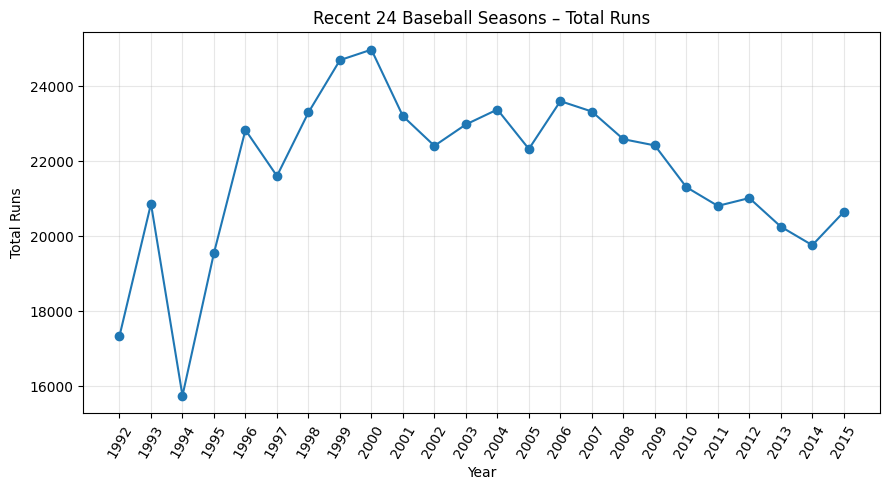

In [3]:
plt.figure(figsize=(9,5))
plt.plot(yearly.index.astype(str), yearly.values, marker="o")
plt.title("Recent 24 Baseball Seasons – Total Runs")
plt.xlabel("Year")
plt.ylabel("Total Runs")
plt.xticks(rotation=60)
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

In [4]:
league_runs = batting.groupby("lgID")["R"].sum().sort_values(ascending=False)
league_runs

lgID
NL    966403.0
AL    849755.0
AA     57307.0
FL      9894.0
PL      7278.0
UA      4825.0
Name: R, dtype: float64

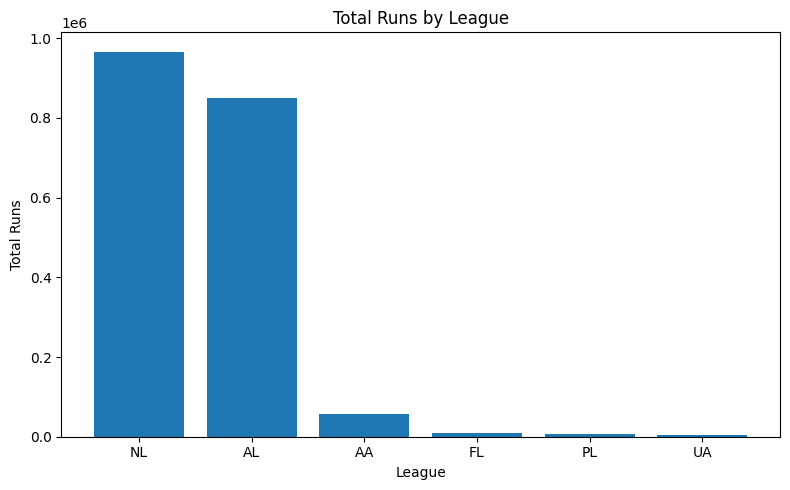

In [5]:
plt.figure(figsize=(8,5))
plt.bar(league_runs.index.astype(str), league_runs.values)
plt.title("Total Runs by League")
plt.xlabel("League")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()

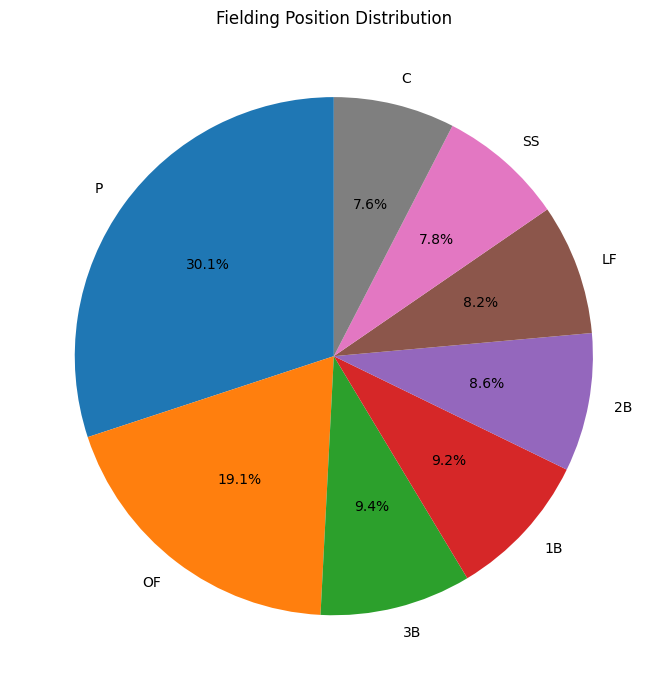

In [6]:
positions = fielding["POS"].value_counts().head(8)
plt.figure(figsize=(7,7))
plt.pie(positions.values, labels=positions.index, autopct="%1.1f%%", startangle=90)
plt.title("Fielding Position Distribution")
plt.tight_layout()
plt.show()

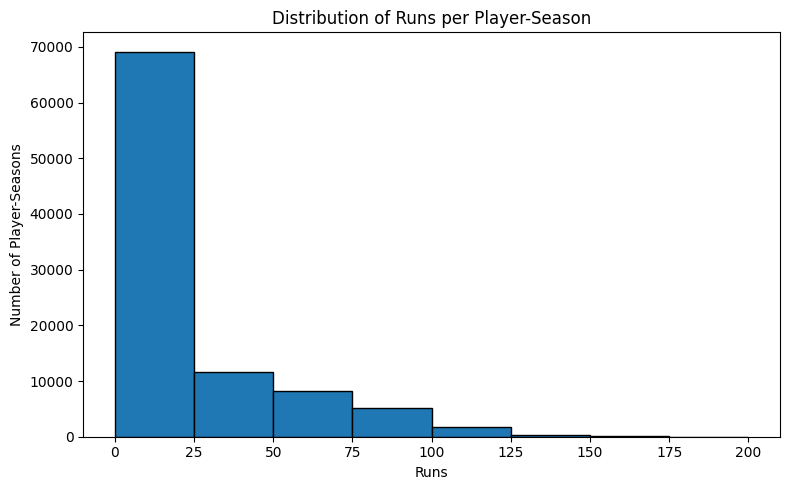

In [7]:
plt.figure(figsize=(8,5))
plt.hist(batting["R"].dropna(), bins=range(0, int(batting["R"].max()) + 25, 25), edgecolor="black")
plt.title("Distribution of Runs per Player-Season")
plt.xlabel("Runs")
plt.ylabel("Number of Player-Seasons")
plt.tight_layout()
plt.show()

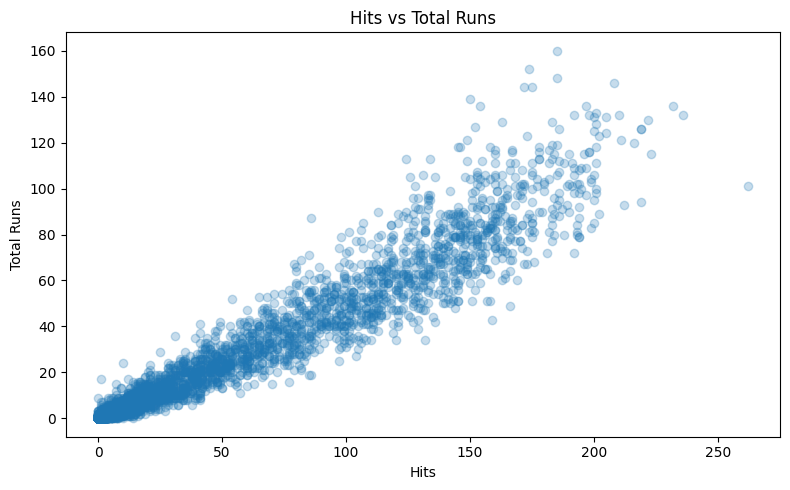

In [8]:
sample = batting.sample(min(5000, len(batting)), random_state=42)
plt.figure(figsize=(8,5))
plt.scatter(sample["H"], sample["R"], alpha=.25)
plt.title("Hits vs Total Runs")
plt.xlabel("Hits")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()